In [1]:
!pip install -q transformers diffusers accelerate gTTS sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 27.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
wandb 0.28.0 requires click>=8.2.0, but you have click 8.1.8 which is incompatible.


In [2]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v0.40.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Topic: The benefits of renewable energy

Loading FLAN-T5 model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Generating image...


  0%|          | 0/30 [00:00<?, ?it/s]

Image saved as: content_image.png


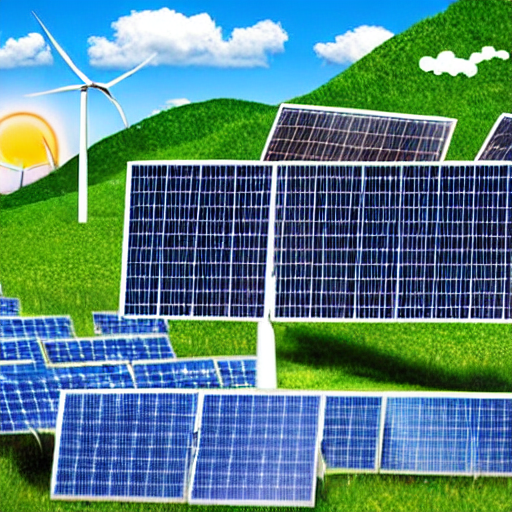


Generating audio...
Audio saved as: content_audio.mp3



       EXPERIMENT 11 COMPLETED
Topic : The benefits of renewable energy
Text  : Generated successfully
Image : content_image.png
Audio : content_audio.mp3


In [3]:
# ============================================
# EXPERIMENT 11 - AI CONTENT GENERATION
# ============================================

import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from diffusers import StableDiffusionPipeline
from gtts import gTTS
from IPython.display import display, Audio

# --------------------------------------------
# 1. HIGH-LEVEL TOPIC
# --------------------------------------------

topic = "The benefits of renewable energy"

print("Topic:", topic)

# --------------------------------------------
# 2. TEXT GENERATION USING FLAN-T5
# --------------------------------------------

print("\nLoading FLAN-T5 model...")

tokenizer = AutoTokenizer.from_pretrained(
    "google/flan-t5-base"
)

text_model = AutoModelForSeq2SeqLM.from_pretrained(
    "google/flan-t5-base"
)

prompt = f"""
Write a short informative paragraph about:
{topic}

Explain its importance and major benefits.
"""

inputs = tokenizer(
    prompt,
    return_tensors="pt"
)

with torch.no_grad():
    output_ids = text_model.generate(
        **inputs,
        max_new_tokens=120
    )

generated_text = tokenizer.decode(
    output_ids[0],
    skip_special_tokens=True
)

print("\n========== GENERATED TEXT ==========")
print(generated_text)

# --------------------------------------------
# 3. IMAGE GENERATION USING STABLE DIFFUSION
# --------------------------------------------

print("\nLoading Stable Diffusion model...")

image_pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
)

image_pipe = image_pipe.to("cuda")

image_prompt = (
    "A realistic and highly detailed visual representation of "
    "renewable energy, solar panels, wind turbines, clean energy, "
    "green environment, digital art"
)

print("Generating image...")

generated_image = image_pipe(
    image_prompt,
    num_inference_steps=30,
    guidance_scale=7.5
).images[0]

generated_image.save("content_image.png")

print("Image saved as: content_image.png")
display(generated_image)

# --------------------------------------------
# 4. AUDIO GENERATION USING gTTS
# --------------------------------------------

print("\nGenerating audio...")

tts = gTTS(
    text=generated_text,
    lang="en"
)

tts.save("content_audio.mp3")

print("Audio saved as: content_audio.mp3")

display(Audio("content_audio.mp3"))

# --------------------------------------------
# 5. FINAL RESULT
# --------------------------------------------

print("\n========================================")
print("       EXPERIMENT 11 COMPLETED")
print("========================================")
print("Topic :", topic)
print("Text  : Generated successfully")
print("Image : content_image.png")
print("Audio : content_audio.mp3")
print("========================================")